In [1]:
import random
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
)

from imblearn.over_sampling import ADASYN

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.models import Sequential

import shap
from lime.lime_tabular import LimeTabularExplainer

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [2]:
data = pd.read_csv("data.csv")

print(f"Shape: {data.shape}")
data.head()

Shape: (1000, 7)


,id,noise_db,water_flow,air_flow,gaccx,outlet_temp,bearings
0,1,40.840517,59.085059,308.289879,0.711820,78.554715,Ok
1,2,40.484226,59.161939,307.833736,0.704667,76.902822,Ok
2,3,40.918572,59.041939,307.377593,0.704828,77.547021,Ok
3,4,40.450953,59.037176,306.975248,0.726604,80.059949,Ok
4,5,41.233739,59.164154,306.832132,0.707785,79.130424,Ok


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           1000 non-null   int64  
 1   noise_db     1000 non-null   float64
 2   water_flow   1000 non-null   float64
 3   air_flow     1000 non-null   float64
 4   gaccx        1000 non-null   float64
 5   outlet_temp  1000 non-null   float64
 6   bearings     1000 non-null   str    
dtypes: float64(5), int64(1), str(1)
memory usage: 54.8 KB


In [4]:
data.describe()

,id,noise_db,water_flow,air_flow,gaccx,outlet_temp
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,53.412121,53.708176,754.673930,0.601789,118.855110
std,288.819436,8.055363,6.587259,442.743491,0.058719,19.120181
min,1.000000,39.879017,38.570791,95.098952,0.540045,76.902822
25%,250.750000,46.490976,50.459245,305.388152,0.558092,104.731080
50%,500.500000,52.708480,58.112667,608.626411,0.576814,118.275842
75%,750.250000,60.158248,58.552897,1193.266273,0.615021,132.850790
max,1000.000000,74.401986,59.174992,1539.911634,0.726604,172.711382


In [5]:
label_columns = ["bearings"]
feature_columns = ["noise_db", "water_flow", "air_flow", "gaccx", "outlet_temp"]

TARGETS = {
    "bearings": {
        "label_map": {"Ok": 0, "Noisy": 1},
        "class_names": ["Ok", "Noisy"],
    },
}

print("Feature columns:", feature_columns)
print(f"Total features: {len(feature_columns)}")
print("\nClass distribution per target:")
for target in label_columns:
    print(f"  {target}: {data[target].value_counts().to_dict()}")

Feature columns: ['noise_db', 'water_flow', 'air_flow', 'gaccx', 'outlet_temp']
Total features: 5

Class distribution per target:
  bearings: {'Ok': 800, 'Noisy': 200}



  MODEL: BEARINGS

Train : {0: 512, 1: 128}
Val   : {0: 128, 1: 32}
Test  : {0: 160, 1: 40}
After ADASYN: {0: 512, 1: 508}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_features (Dense)         │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 737 (2.88 KB)

 Trainable params: 737 (2.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5333 - loss: 0.6866 - val_accuracy: 0.5375 - val_loss: 0.6904
Epoch 2/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5833 - loss: 0.6769 - val_accuracy: 0.4500 - val_loss: 0.6855
Epoch 3/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6157 - loss: 0.6634 - val_accuracy: 0.4812 - val_loss: 0.6681
Epoch 4/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6627 - loss: 0.6460 - val_accuracy: 0.5625 - val_loss: 0.6447
Epoch 5/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6353 - loss: 0.6365 - val_accuracy: 0.5813 - val_loss: 0.6229
Epoch 6/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6696 - loss: 0.6214 - val_accuracy: 0.7000 - val_loss: 0.5926
Epoch 7/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6775 - loss: 0.6071 - val_accuracy: 0.6812 - val_loss: 0.5766
Epoch 8/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6990 - loss: 0.5890 - val_accuracy: 0.6438 - 

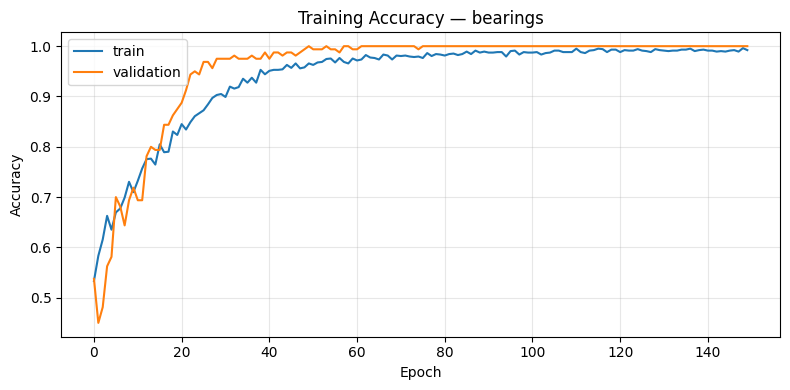


--- Metrics ---
  accuracy: 0.9900
  balanced_accuracy: 0.9750
  f1_fault: 0.9744
  roc_auc: 1.0000
              precision    recall  f1-score   support

          Ok       0.99      1.00      0.99       160
       Noisy       1.00      0.95      0.97        40

    accuracy                           0.99       200
   macro avg       0.99      0.97      0.98       200
weighted avg       0.99      0.99      0.99       200



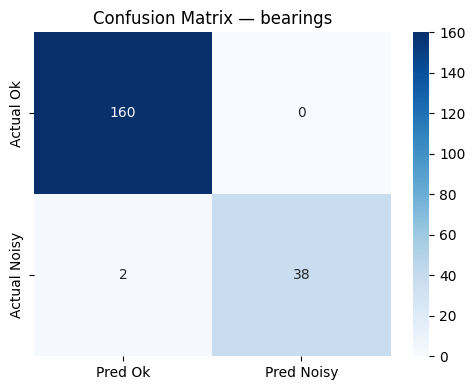

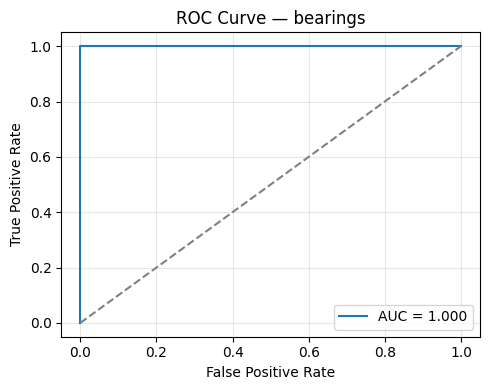

  0%|          | 0/50 [00:00<?, ?it/s]

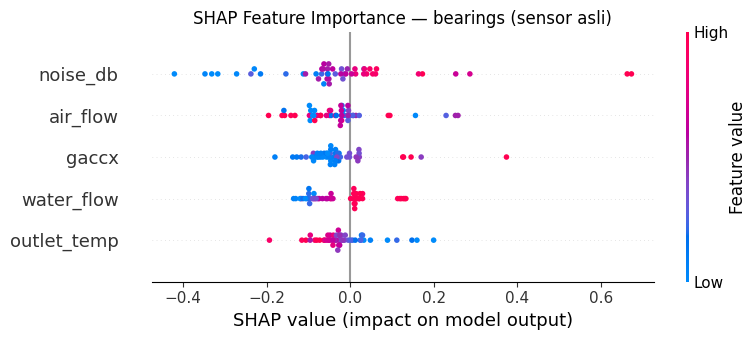

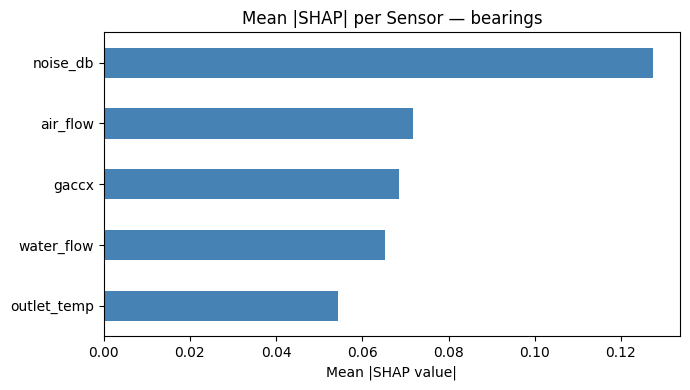

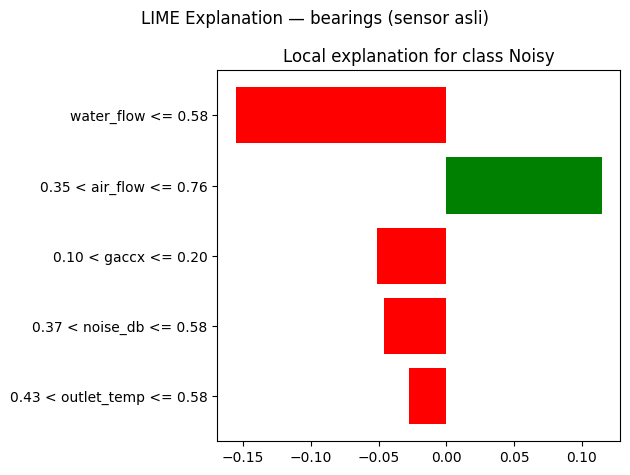

Saved: models/hybrid_model_bearings.pkl


In [6]:
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

all_metrics = {}

for target_column, config in TARGETS.items():
    print(f"\n{'='*60}")
    print(f"  MODEL: {target_column.upper()}")
    print(f"{'='*60}\n")

    label_map = config["label_map"]
    class_names = config["class_names"]

    X = data[feature_columns].copy()
    y = data[target_column].map(label_map)

    # --- Split ---
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )
    X_train_raw, X_val_raw, y_train, y_val = train_test_split(
        X_train_raw, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE
    )

    print(f"Train : {y_train.value_counts().to_dict()}")
    print(f"Val   : {y_val.value_counts().to_dict()}")
    print(f"Test  : {y_test.value_counts().to_dict()}")

    # --- Scale ---
    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_val   = scaler.transform(X_val_raw)
    X_test  = scaler.transform(X_test_raw)

    # --- ADASYN ---
    adasyn = ADASYN(random_state=RANDOM_STATE)
    X_train_res, y_train_res = adasyn.fit_resample(X_train, y_train)
    print(f"After ADASYN: {pd.Series(y_train_res).value_counts().to_dict()}")

    # --- DNN ---
    tf.random.set_seed(RANDOM_STATE)
    model = Sequential([
        Input(shape=(X_train_res.shape[1],)),
        Dense(32, activation="relu"),
        Dropout(0.3),
        Dense(16, activation="relu", name="latent_features"),
        Dropout(0.3),
        Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    model.summary()

    early_stop = EarlyStopping(
        monitor="val_loss", patience=20, restore_best_weights=True
    )
    history = model.fit(
        X_train_res, y_train_res,
        epochs=150,
        batch_size=64,
        validation_data=(X_val, y_val),
        callbacks=[early_stop],
        shuffle=True,
        verbose=1,
    )

    # Training history
    plt.figure(figsize=(8, 4))
    plt.plot(history.history["accuracy"], label="train")
    plt.plot(history.history["val_accuracy"], label="validation")
    plt.title(f"Training Accuracy — {target_column}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- Feature extractor ---
    feature_extractor = tf.keras.Model(
        inputs=model.inputs,
        outputs=model.get_layer("latent_features").output,
    )
    train_features_res = feature_extractor.predict(X_train_res, verbose=0)
    val_features       = feature_extractor.predict(X_val, verbose=0)
    test_features      = feature_extractor.predict(X_test, verbose=0)

    # --- SVM ---
    svm = SVC(
        kernel="rbf", C=10, gamma="scale",
        class_weight="balanced", probability=True,
        random_state=RANDOM_STATE,
    )
    svm.fit(train_features_res, y_train_res)

    # --- Evaluation ---
    pred   = svm.predict(test_features)
    y_prob = svm.predict_proba(test_features)[:, 1]

    metrics = {
        "accuracy": accuracy_score(y_test, pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred),
        "f1_fault": f1_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, y_prob),
    }
    all_metrics[target_column] = metrics

    print("\n--- Metrics ---")
    for name, value in metrics.items():
        print(f"  {name}: {value:.4f}")
    print(classification_report(y_test, pred, target_names=class_names))

    # Confusion matrix
    cm = confusion_matrix(y_test, pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=[f"Pred {c}" for c in class_names],
        yticklabels=[f"Actual {c}" for c in class_names],
    )
    plt.title(f"Confusion Matrix — {target_column}")
    plt.tight_layout()
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC = {metrics['roc_auc']:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.title(f"ROC Curve — {target_column}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- SHAP (pipeline end-to-end: sensor asli -> DNN -> SVM) ---
    def pipeline_predict_proba(X_sensor):
        latent = feature_extractor.predict(X_sensor, verbose=0)
        return svm.predict_proba(latent)

    shap_background = shap.sample(X_train, 100, random_state=RANDOM_STATE)
    shap_explainer = shap.KernelExplainer(
        pipeline_predict_proba,
        shap_background,
    )
    shap_values = shap_explainer.shap_values(X_test[:50])
    # shap_values shape: [n_classes, n_samples, n_features] atau [n_samples, n_features]
    # shap_values shape: (n_samples, n_features, n_classes) -> ambil kelas fault (index 1)
    import numpy as np
    sv_arr = np.array(shap_values)
    if sv_arr.ndim == 3:
        sv_fault = sv_arr[:, :, 1]   # (n_samples, n_features) untuk kelas Noisy/Dirty
    elif isinstance(shap_values, list):
        sv_fault = np.array(shap_values[1])
    else:
        sv_fault = sv_arr
    shap.summary_plot(sv_fault, X_test[:50], feature_names=feature_columns, show=False)
    plt.title(f"SHAP Feature Importance — {target_column} (sensor asli)")
    plt.tight_layout()
    plt.show()

    # Bar plot rata-rata |SHAP| per sensor
    mean_shap = np.abs(sv_fault).mean(axis=0)
    shap_df = pd.Series(mean_shap, index=feature_columns).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(7, 4))
    shap_df.plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(f"Mean |SHAP| per Sensor — {target_column}")
    ax.set_xlabel("Mean |SHAP value|")
    plt.tight_layout()
    plt.show()

    # --- LIME (pipeline end-to-end: sensor asli -> DNN -> SVM) ---
    lime_explainer = LimeTabularExplainer(
        X_train,
        feature_names=feature_columns,
        class_names=class_names,
        mode="classification",
        discretize_continuous=True,
        random_state=RANDOM_STATE,
    )
    lime_exp = lime_explainer.explain_instance(
        X_test[0], pipeline_predict_proba, num_features=len(feature_columns)
    )
    fig = lime_exp.as_pyplot_figure()
    fig.suptitle(f"LIME Explanation — {target_column} (sensor asli)")
    plt.tight_layout()
    plt.show()

    # --- Save ---
    model.save(models_dir / f"dnn_{target_column}.keras")
    feature_extractor.save(models_dir / f"dnn_extractor_{target_column}.keras")
    joblib.dump(
        {
            "scaler": scaler,
            "svm": svm,
            "feature_columns": feature_columns,
            "target_column": target_column,
            "label_mapping": label_map,
            "class_names": class_names,
            "metrics": metrics,
        },
        models_dir / f"hybrid_model_{target_column}.pkl",
    )
    print(f"Saved: models/hybrid_model_{target_column}.pkl")


  RINGKASAN METRICS — BEARING
  Accuracy        : 0.9900
  Balanced Acc    : 0.9750
  F1 Fault        : 0.9744
  ROC-AUC         : 1.0000


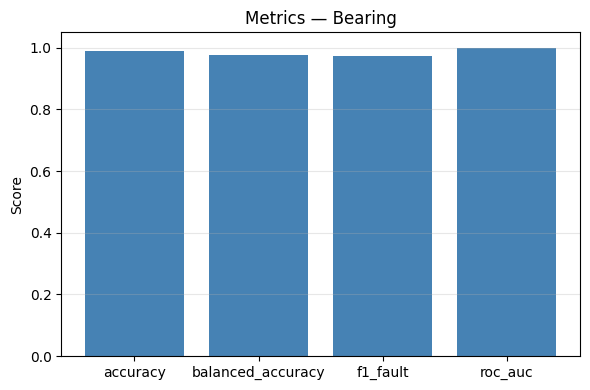

In [7]:
target_column = "bearings"
metrics = all_metrics[target_column]

print("\n" + "="*60)
print("  RINGKASAN METRICS — BEARING")
print("="*60)

print(f"  Accuracy        : {metrics['accuracy']:.4f}")
print(f"  Balanced Acc    : {metrics['balanced_accuracy']:.4f}")
print(f"  F1 Fault        : {metrics['f1_fault']:.4f}")
print(f"  ROC-AUC         : {metrics['roc_auc']:.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(metrics.keys(), metrics.values(), color="steelblue")
ax.set_title("Metrics — Bearing")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# Kesimpulan Pipeline
#
# Dataset  : data.csv — 1000 baris, 5 sensor, 1 label komponen (bearings)
# Sensor   : noise_db, water_flow, air_flow, gaccx, outlet_temp
#            (dipilih berdasarkan Random Forest feature importance)
# Target   : bearings (Ok / Noisy)
# Metode   : DNN (feature extractor 16-dim) + SVM RBF (classifier)
#
# Pipeline:
# 1. Sensor dipilih: 5 sensor paling berpengaruh untuk komponen bearing.
# 2. Split stratified: 64% train / 16% validation / 20% test.
# 3. MinMaxScaler hanya fit pada data train (mencegah data leakage).
# 4. ADASYN hanya pada train set untuk menangani class imbalance (800 Ok : 200 Noisy).
# 5. DNN mengekstrak 16 fitur laten dari 5 sensor.
# 6. SVM RBF mengklasifikasikan fitur laten.
# 7. Evaluasi: accuracy, balanced accuracy, F1 fault, ROC-AUC.
# 8. SHAP (global) + LIME (lokal) untuk explainability.
# 9. Model disimpan di folder models/.